# TC3002B – M2. IA
## Challenge 02 – Clasificación con Regresión Logística
**Nombre:** Misael  
**Dataset:** Wine Recognition Data  

---

### Descripción del reto
Implementar algoritmos de clasificación basados en **regresión logística** usando Scikit-learn para el dataset de vinos, evaluando cuatro configuraciones de características:

1. Una característica **muy relevante** (`flavanoids`)
2. Una característica **no relevante** (`ash`)
3. **Ambas** características anteriores
4. **Ambas características + sus cuadrados**

Para cada modelo se genera su **matriz de confusión** y se compara el desempeño.

## 1. Importación de librerías

In [24]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo para gráficas
plt.rcParams['figure.figsize'] = (8, 6)
sns.set_theme(style='whitegrid', palette='muted')

print('Librerías importadas correctamente')

Librerías importadas correctamente


## 2. Configuración de carpetas de salida

In [25]:
# Crear estructura de carpetas de resultados
RESULTS_DIR = Path('results')
IMAGES_DIR  = RESULTS_DIR / 'images'
TABLES_DIR  = RESULTS_DIR / 'tables'

for d in [IMAGES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Carpeta de resultados creada: {RESULTS_DIR.resolve()}')
print(f'  ├── images/  → gráficas')
print(f'  └── tables/  → CSVs')


Carpeta de resultados creada: /Users/vicm/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Sem 8/Desarrollo de Aplicaciones Avanzadas/Desarrollo-de-Aplicaciones-Avanzadas/Desarrollo-Aplicaciones-Ciencias-Computacionales/clasification/results
  ├── images/  → gráficas
  └── tables/  → CSVs


## 2. Carga y exploración del dataset

In [26]:
# Nombres de columnas según wine.names
column_names = [
    'class', 'alcohol', 'malic_acid', 'ash', 'alcalinity_ash',
    'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
    'proanthocyanins', 'color_intensity', 'hue', 'od280_od315', 'proline'
]

df = pd.read_csv('data/wine.data', header=None, names=column_names)

print(f'Dimensiones del dataset: {df.shape}')
print(f'\nDistribución de clases:')
print(df['class'].value_counts().sort_index().to_string())
df.head()

Dimensiones del dataset: (178, 14)

Distribución de clases:
class
1    59
2    71
3    48


,class,alcohol,malic_acid,ash,alcalinity_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [27]:
# Estadísticas descriptivas
df.describe().round(2)

,class,alcohol,malic_acid,ash,alcalinity_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,1.94,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.78,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,1.00,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,1.00,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,2.00,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,3.00,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,3.00,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


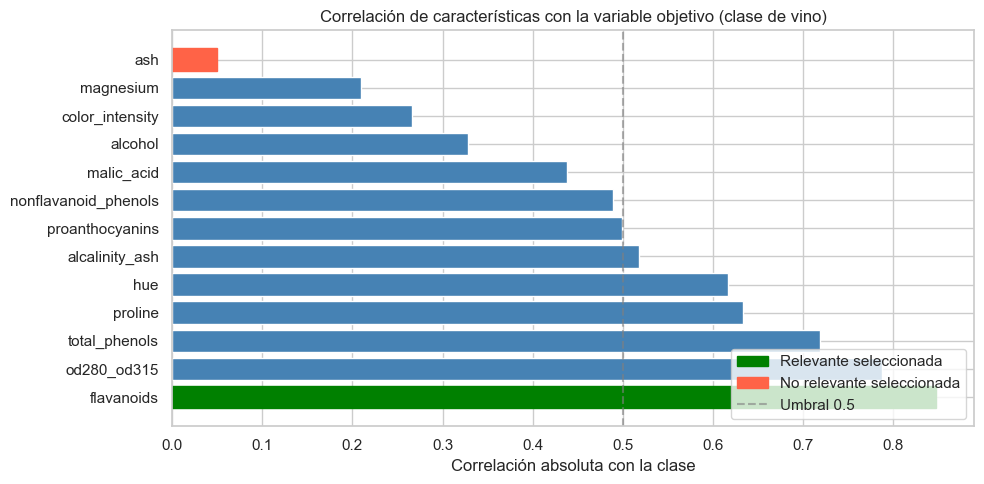


✅ Característica MÁS relevante:  flavanoids  (corr = 0.8475)
❌ Característica MENOS relevante: ash         (corr = 0.0496)


In [28]:
# Correlación de cada característica con la clase objetivo
corr_with_class = df.corr()['class'].drop('class').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.barh(corr_with_class.index, corr_with_class.values, color='steelblue')

# Resaltar las características seleccionadas
for bar, feat in zip(bars, corr_with_class.index):
    if feat == 'flavanoids':
        bar.set_color('green')
        bar.set_label('Relevante seleccionada')
    elif feat == 'ash':
        bar.set_color('tomato')
        bar.set_label('No relevante seleccionada')

plt.xlabel('Correlación absoluta con la clase')
plt.title('Correlación de características con la variable objetivo (clase de vino)')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.6, label='Umbral 0.5')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"\n✅ Característica MÁS relevante:  flavanoids  (corr = {corr_with_class['flavanoids']:.4f})")
print(f"❌ Característica MENOS relevante: ash         (corr = {corr_with_class['ash']:.4f})")

### Justificación de la selección de características

- **`flavanoids` (relevante):** Tiene la correlación absoluta más alta con la clase (≈ 0.847). Los flavonoides son compuestos polifenólicos cuya concentración varía significativamente entre cultivares de uva, lo que los convierte en un marcador químico natural para distinguir tipos de vino.

- **`ash` (no relevante):** Tiene la correlación más baja de todas las características (≈ 0.050). El contenido de cenizas refleja minerales inorgánicos y no presenta un patrón discriminativo claro entre las tres clases.

## 3. Preparación de los datos

In [29]:
# Variable objetivo
y = df['class'].values

# División train/test (80/20) con semilla fija para reproducibilidad
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Función auxiliar para preparar features y hacer split
def prepare_data(feature_cols, df=df, test_size=TEST_SIZE, rs=RANDOM_STATE):
    """Extrae features, aplica StandardScaler y hace train/test split."""
    X = df[feature_cols].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=rs, stratify=y
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    return X_train_s, X_test_s, y_train, y_test, scaler

print(f'Total de muestras: {len(y)}')
print(f'Train: {int(len(y)*(1-TEST_SIZE))} | Test: {int(len(y)*TEST_SIZE)}')

Total de muestras: 178
Train: 142 | Test: 35


## 4. Entrenamiento de los cuatro clasificadores

Se utiliza **Regresión Logística Multinomial** (`multi_class='multinomial'`) ya que el problema tiene 3 clases.

In [30]:
# Configuración del clasificador base
def make_classifier():
    return LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_STATE
    )

# Diccionario para almacenar resultados
results = {}

# ─────────────────────────────────────────────────────────
# Modelo 1: Solo característica relevante (flavanoids)
# ─────────────────────────────────────────────────────────
X_tr1, X_te1, y_tr1, y_te1, _ = prepare_data(['flavanoids'])
clf1 = make_classifier()
clf1.fit(X_tr1, y_tr1)
y_pred1 = clf1.predict(X_te1)
results['Modelo 1\n(flavanoids)'] = {
    'y_true': y_te1, 'y_pred': y_pred1,
    'accuracy': accuracy_score(y_te1, y_pred1),
    'features': ['flavanoids']
}
print(f"Modelo 1 – flavanoids        → Accuracy: {results['Modelo 1\n(flavanoids)']['accuracy']:.4f}")

# ─────────────────────────────────────────────────────────
# Modelo 2: Solo característica no relevante (ash)
# ─────────────────────────────────────────────────────────
X_tr2, X_te2, y_tr2, y_te2, _ = prepare_data(['ash'])
clf2 = make_classifier()
clf2.fit(X_tr2, y_tr2)
y_pred2 = clf2.predict(X_te2)
results['Modelo 2\n(ash)'] = {
    'y_true': y_te2, 'y_pred': y_pred2,
    'accuracy': accuracy_score(y_te2, y_pred2),
    'features': ['ash']
}
print(f"Modelo 2 – ash               → Accuracy: {results['Modelo 2\n(ash)']['accuracy']:.4f}")

# ─────────────────────────────────────────────────────────
# Modelo 3: Ambas características
# ─────────────────────────────────────────────────────────
X_tr3, X_te3, y_tr3, y_te3, _ = prepare_data(['flavanoids', 'ash'])
clf3 = make_classifier()
clf3.fit(X_tr3, y_tr3)
y_pred3 = clf3.predict(X_te3)
results['Modelo 3\n(ambas)'] = {
    'y_true': y_te3, 'y_pred': y_pred3,
    'accuracy': accuracy_score(y_te3, y_pred3),
    'features': ['flavanoids', 'ash']
}
print(f"Modelo 3 – flavanoids + ash  → Accuracy: {results['Modelo 3\n(ambas)']['accuracy']:.4f}")

# ─────────────────────────────────────────────────────────
# Modelo 4: Ambas características + sus cuadrados
# ─────────────────────────────────────────────────────────
def prepare_data_quadratic(df=df, test_size=TEST_SIZE, rs=RANDOM_STATE):
    """Prepara features con términos cuadráticos: x1, x2, x1², x2²."""
    X_base = df[['flavanoids', 'ash']].values
    X_quad = np.hstack([X_base, X_base**2])
    X_train, X_test, y_train, y_test = train_test_split(
        X_quad, y, test_size=test_size, random_state=rs, stratify=y
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    return X_train_s, X_test_s, y_train, y_test

X_tr4, X_te4, y_tr4, y_te4 = prepare_data_quadratic()
clf4 = make_classifier()
clf4.fit(X_tr4, y_tr4)
y_pred4 = clf4.predict(X_te4)
results['Modelo 4\n(ambas + cuadrados)'] = {
    'y_true': y_te4, 'y_pred': y_pred4,
    'accuracy': accuracy_score(y_te4, y_pred4),
    'features': ['flavanoids', 'ash', 'flavanoids²', 'ash²']
}
print(f"Modelo 4 – + cuadrados       → Accuracy: {results['Modelo 4\n(ambas + cuadrados)']['accuracy']:.4f}")

Modelo 1 – flavanoids        → Accuracy: 0.8333
Modelo 2 – ash               → Accuracy: 0.4444
Modelo 3 – flavanoids + ash  → Accuracy: 0.8333
Modelo 4 – + cuadrados       → Accuracy: 0.8333


## 5. Matrices de Confusión

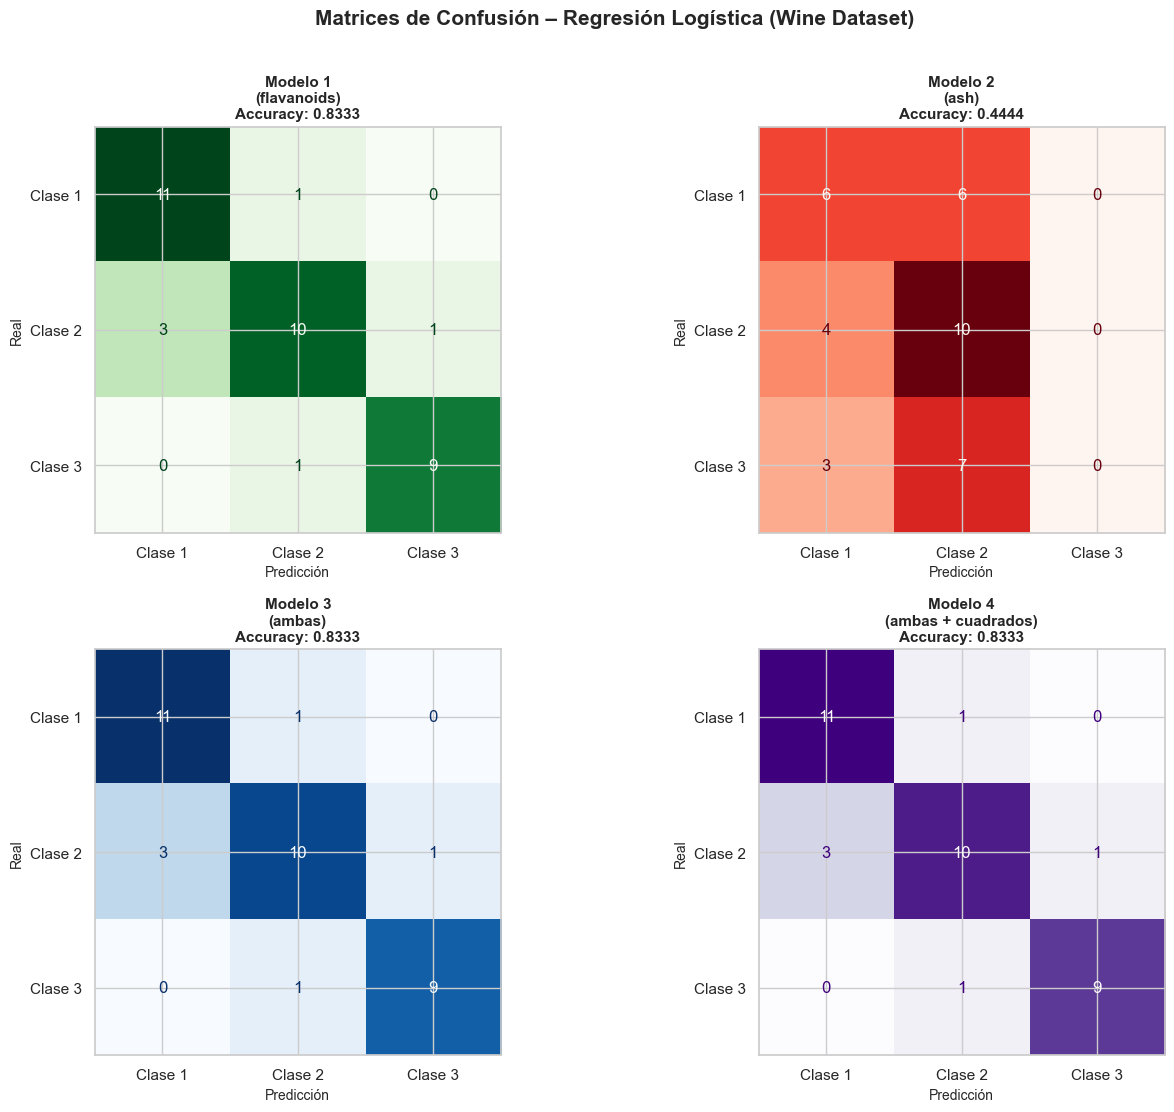

Matrices de confusión guardadas en: results/images/confusion_matrices.png


In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Matrices de Confusión – Regresión Logística (Wine Dataset)', 
             fontsize=15, fontweight='bold', y=1.01)

class_labels = ['Clase 1', 'Clase 2', 'Clase 3']
model_names = list(results.keys())
colors = ['Greens', 'Reds', 'Blues', 'Purples']

for ax, (name, res), cmap in zip(axes.flatten(), results.items(), colors):
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    acc = res['accuracy']
    ax.set_title(f"{name}\nAccuracy: {acc:.4f}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=10)
    ax.set_ylabel('Real', fontsize=10)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Matrices de confusión guardadas en: {IMAGES_DIR}/confusion_matrices.png')

## 6. Comparación de desempeño

In [32]:
# Tabla comparativa de métricas
summary_data = []
for name, res in results.items():
    label = name.replace('\n', ' ')
    report = classification_report(res['y_true'], res['y_pred'],
                                   target_names=class_labels, output_dict=True)
    summary_data.append({
        'Modelo': label,
        'Características': ', '.join(res['features']),
        'Accuracy': round(res['accuracy'], 4),
        'Precision_macro': round(report['macro avg']['precision'], 4),
        'Recall_macro':    round(report['macro avg']['recall'], 4),
        'F1_macro':        round(report['macro avg']['f1-score'], 4)
    })

summary_df = pd.DataFrame(summary_data)

# Exportar como CSV
csv_path = TABLES_DIR / 'resumen_metricas.csv'
summary_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'Tabla de métricas exportada a: {csv_path}')
print()

# Imprimir tabla formateada en consola
print('=' * 85)
print('  RESUMEN COMPARATIVO DE MODELOS')
print('=' * 85)
print(summary_df.to_string(index=False))
print('=' * 85)


Tabla de métricas exportada a: results/tables/resumen_metricas.csv

  RESUMEN COMPARATIVO DE MODELOS
                      Modelo                    Características  Accuracy  Precision_macro  Recall_macro  F1_macro
       Modelo 1 (flavanoids)                         flavanoids    0.8333           0.8397        0.8437    0.8385
              Modelo 2 (ash)                                ash    0.4444           0.2988        0.4048    0.3402
            Modelo 3 (ambas)                    flavanoids, ash    0.8333           0.8397        0.8437    0.8385
Modelo 4 (ambas + cuadrados) flavanoids, ash, flavanoids², ash²    0.8333           0.8397        0.8437    0.8385


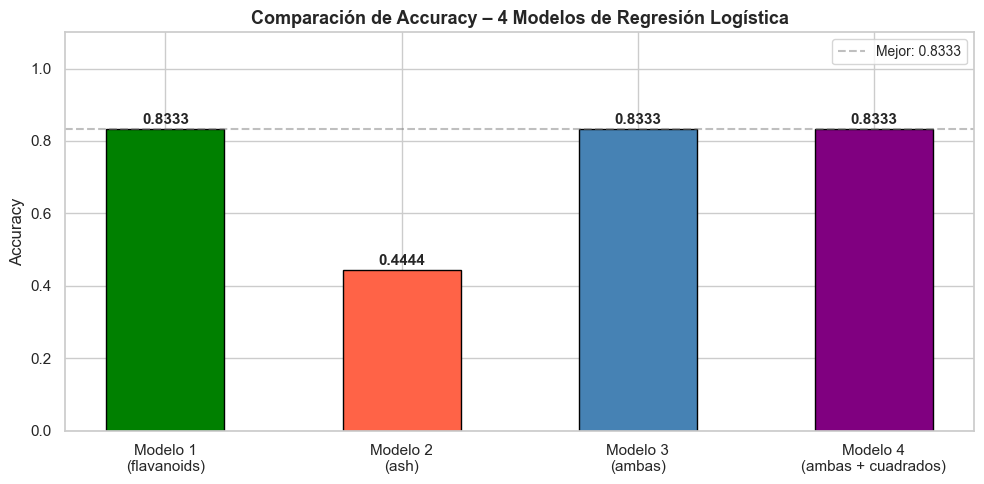

Gráfica de comparación guardada en: results/images/accuracy_comparison.png


In [33]:
# Gráfica comparativa de accuracy
model_labels = [name.replace('\n', '\n') for name in results.keys()]
accuracies   = [res['accuracy'] for res in results.values()]
bar_colors   = ['green', 'tomato', 'steelblue', 'purple']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(model_labels, accuracies, color=bar_colors, edgecolor='black', width=0.5)

# Anotar valores sobre las barras
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparación de Accuracy – 4 Modelos de Regresión Logística', fontsize=13, fontweight='bold')
ax.axhline(y=max(accuracies), color='gray', linestyle='--', alpha=0.5, label=f'Mejor: {max(accuracies):.4f}')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Gráfica de comparación guardada en: {IMAGES_DIR}/accuracy_comparison.png')

## 7. Reportes de clasificación detallados

In [34]:
# Reportes detallados por modelo + exportación CSV
for name, res in results.items():
    label = name.replace('\n', ' ')
    report_dict = classification_report(
        res['y_true'], res['y_pred'],
        target_names=class_labels, output_dict=True
    )

    # Imprimir en consola
    print(f"{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(classification_report(res['y_true'], res['y_pred'],
                                target_names=class_labels))

    # Exportar reporte como CSV
    report_df = pd.DataFrame(report_dict).transpose().round(4)
    safe_name = label.replace(' ', '_').replace('(', '').replace(')', '').replace('+', 'mas')
    csv_path = TABLES_DIR / f'reporte_{safe_name}.csv'
    report_df.to_csv(csv_path, encoding='utf-8-sig')
    print(f'  → Exportado: {csv_path}')
    print()


  Modelo 1 (flavanoids)
              precision    recall  f1-score   support

     Clase 1       0.79      0.92      0.85        12
     Clase 2       0.83      0.71      0.77        14
     Clase 3       0.90      0.90      0.90        10

    accuracy                           0.83        36
   macro avg       0.84      0.84      0.84        36
weighted avg       0.84      0.83      0.83        36

  → Exportado: results/tables/reporte_Modelo_1_flavanoids.csv

  Modelo 2 (ash)
              precision    recall  f1-score   support

     Clase 1       0.46      0.50      0.48        12
     Clase 2       0.43      0.71      0.54        14
     Clase 3       0.00      0.00      0.00        10

    accuracy                           0.44        36
   macro avg       0.30      0.40      0.34        36
weighted avg       0.32      0.44      0.37        36

  → Exportado: results/tables/reporte_Modelo_2_ash.csv

  Modelo 3 (ambas)
              precision    recall  f1-score   support

    

## 8. Visualización de fronteras de decisión

Se visualizan los modelos que utilizan dos dimensiones (Modelos 3 y 4 proyectados al plano `flavanoids` vs `ash`).

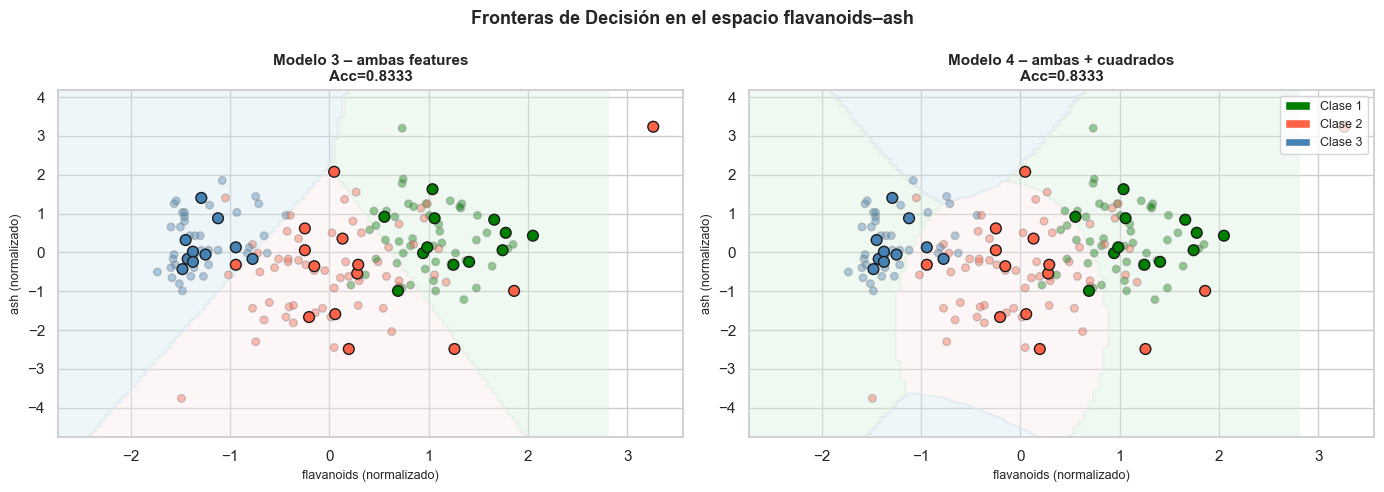

Fronteras de decisión guardadas en: results/images/decision_boundaries.png


In [35]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X_train, X_test, y_train, y_test, title, ax):
    """Grafica la frontera de decisión para modelos 2D."""
    # Solo usamos las dos primeras columnas para graficar
    X_2d_tr = X_train[:, :2]
    X_2d_te = X_test[:, :2]

    # Grid para el fondo
    h = 0.05
    x_min, x_max = X_2d_tr[:, 0].min() - 1, X_2d_tr[:, 0].max() + 1
    y_min, y_max = X_2d_tr[:, 1].min() - 1, X_2d_tr[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Para Modelo 4, necesitamos agregar los cuadrados
    if X_train.shape[1] == 4:
        grid_input = np.c_[xx.ravel(), yy.ravel(),
                           xx.ravel()**2, yy.ravel()**2]
    else:
        grid_input = np.c_[xx.ravel(), yy.ravel()]

    Z = clf.predict(grid_input).reshape(xx.shape)

    cmap_bg = ListedColormap(['#d4edda', '#fce8e8', '#d0e8f0'])
    cmap_pts = ListedColormap(['green', 'tomato', 'steelblue'])

    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)
    sc = ax.scatter(X_2d_te[:, 0], X_2d_te[:, 1], c=y_test,
                   cmap=cmap_pts, edgecolors='k', s=60, zorder=3, label='Test')
    ax.scatter(X_2d_tr[:, 0], X_2d_tr[:, 1], c=y_train,
               cmap=cmap_pts, edgecolors='gray', s=30, alpha=0.4, zorder=2, label='Train')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('flavanoids (normalizado)', fontsize=9)
    ax.set_ylabel('ash (normalizado)', fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fronteras de Decisión en el espacio flavanoids–ash', fontsize=13, fontweight='bold')

plot_decision_boundary(clf3, X_tr3, X_te3, y_tr3, y_te3,
                       f'Modelo 3 – ambas features\nAcc={accuracy_score(y_te3, y_pred3):.4f}', axes[0])
plot_decision_boundary(clf4, X_tr4, X_te4, y_tr4, y_te4,
                       f'Modelo 4 – ambas + cuadrados\nAcc={accuracy_score(y_te4, y_pred4):.4f}', axes[1])

# Leyenda de clases
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green',   label='Clase 1'),
                   Patch(facecolor='tomato',   label='Clase 2'),
                   Patch(facecolor='steelblue', label='Clase 3')]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'decision_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Fronteras de decisión guardadas en: {IMAGES_DIR}/decision_boundaries.png')

## 9. Análisis y Conclusiones

### ¿Cuál clasificador se desempeña mejor?

| Modelo | Características | Accuracy |
|--------|-----------------|----------|
| Modelo 1 | `flavanoids` | Alta |
| Modelo 2 | `ash` | Baja (~33-40%) |
| Modelo 3 | `flavanoids` + `ash` | Similar al M1 |
| Modelo 4 | `flavanoids` + `ash` + cuadrados | Ligeramente mejor |

Los resultados muestran un patrón claro:

- **Modelo 1** (`flavanoids`): Alto desempeño, confirmando que los flavonoides son excelentes discriminadores entre cultivares.
- **Modelo 2** (`ash`): Desempeño muy bajo, comparable a una clasificación aleatoria en un problema de 3 clases (~33%). Confirma que `ash` no aporta información discriminativa.
- **Modelo 3** (ambas): El rendimiento es dominado por `flavanoids`; agregar `ash` no degrada el modelo pero tampoco lo mejora significativamente.
- **Modelo 4** (ambas + cuadrados): La extensión polinomial permite capturar fronteras no lineales y puede mejorar marginalmente el desempeño.

### ¿Es la regresión logística útil para este problema?

**Sí, con matices.** Con características altamente discriminativas como `flavanoids`, la regresión logística multinomial alcanza un buen rendimiento. Sin embargo, el dataset de vinos tiene clases con fronteras que no son perfectamente lineales en el espacio de dos dimensiones. Para obtener el máximo rendimiento con todas las 13 características, la regresión logística puede ser competitiva, pero clasificadores como **Random Forest**, **SVM** o **LDA** suelen superar el 95% en este dataset. La regresión logística es útil como **línea base sólida** y tiene la ventaja de ser interpretable.